In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [17]:
import zipfile
import os

with zipfile.ZipFile("online+retail.zip", "r") as zip_ref:
    zip_ref.extractall("online_retail_data")

os.listdir("online_retail_data")

['Online Retail.xlsx']

In [28]:
df = pd.read_excel("online_retail_data/Online Retail.xlsx")

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [29]:
df.shape

(541909, 8)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [31]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [33]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [34]:
df.duplicated().sum()

np.int64(5268)

In [35]:
df = df.drop_duplicates()

In [36]:
df.shape

(536641, 8)

In [37]:
df['CustomerID'].isnull().sum()

np.int64(135037)

In [39]:
df = df.dropna(subset=['CustomerID'])

In [40]:
df['CustomerID'].isnull().sum()

np.int64(0)

In [41]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8872)

In [42]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [43]:
df.shape

(392732, 8)

In [44]:
df['Quantity'].min()

1

In [45]:
df['UnitPrice'].min()

0.0

In [46]:
df = df[df['Quantity'] > 0]

In [47]:
df = df[df['UnitPrice'] > 0]

In [48]:
df.shape

(392692, 8)

In [49]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [50]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [51]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [52]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [53]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Month_Name'] = df['InvoiceDate'].dt.strftime('%B')

In [54]:
df[['InvoiceDate', 'Year', 'Month', 'Month_Name']].head()

,InvoiceDate,Year,Month,Month_Name
0,2010-12-01 08:26:00,2010,12,December
1,2010-12-01 08:26:00,2010,12,December
2,2010-12-01 08:26:00,2010,12,December
3,2010-12-01 08:26:00,2010,12,December
4,2010-12-01 08:26:00,2010,12,December


In [55]:
df.shape

(392692, 12)

In [56]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0
Year,0


In [57]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December


In [58]:
total_revenue = df['Revenue'].sum()
total_revenue

np.float64(8887208.894)

In [59]:
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,887,208.89


In [60]:
total_orders = df['InvoiceNo'].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 18,532


In [61]:
total_customers = df['CustomerID'].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 4,338


In [62]:
average_order_value = total_revenue / total_orders
print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £479.56


In [63]:
print("===== E-COMMERCE KPI SUMMARY =====")
print(f"Total Revenue:       £{total_revenue:,.2f}")
print(f"Total Orders:        {total_orders:,}")
print(f"Total Customers:     {total_customers:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

===== E-COMMERCE KPI SUMMARY =====
Total Revenue:       £8,887,208.89
Total Orders:        18,532
Total Customers:     4,338
Average Order Value: £479.56


In [64]:
monthly_revenue = df.groupby('Month_Name')['Revenue'].sum()

monthly_revenue

,Revenue
Month_Name,
April,468374.331
August,644051.040
December,1087613.170
February,446084.920
January,568101.310
July,598962.901
June,660046.050
March,594081.760
May,677355.150


In [65]:
monthly_revenue = df.groupby(['Month','Month_Name'])['Revenue'].sum().reset_index()

monthly_revenue

,Month,Month_Name,Revenue
0,1,January,568101.310
1,2,February,446084.920
2,3,March,594081.760
3,4,April,468374.331
4,5,May,677355.150
5,6,June,660046.050
6,7,July,598962.901
7,8,August,644051.040
8,9,September,950690.202
9,10,October,1035642.450


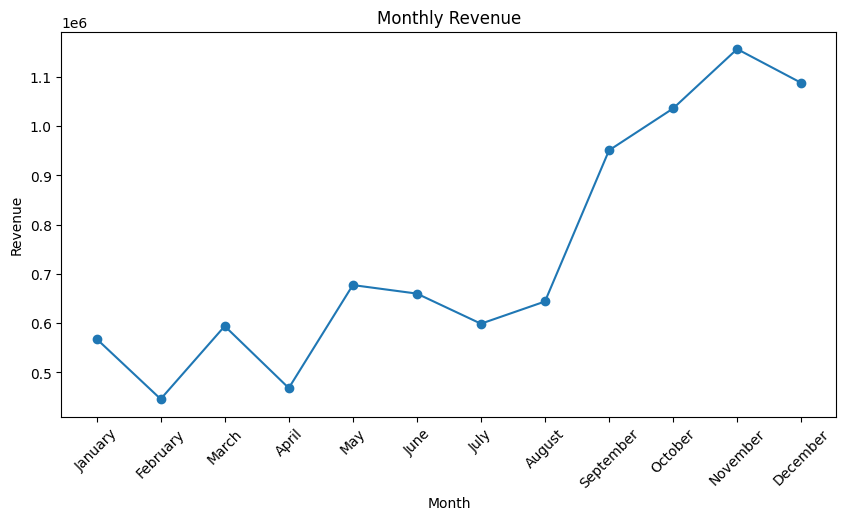

In [66]:
plt.figure(figsize=(10,5))

plt.plot(monthly_revenue['Month_Name'],
         monthly_revenue['Revenue'],
         marker='o')

plt.xticks(rotation=45)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [67]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

top_products

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


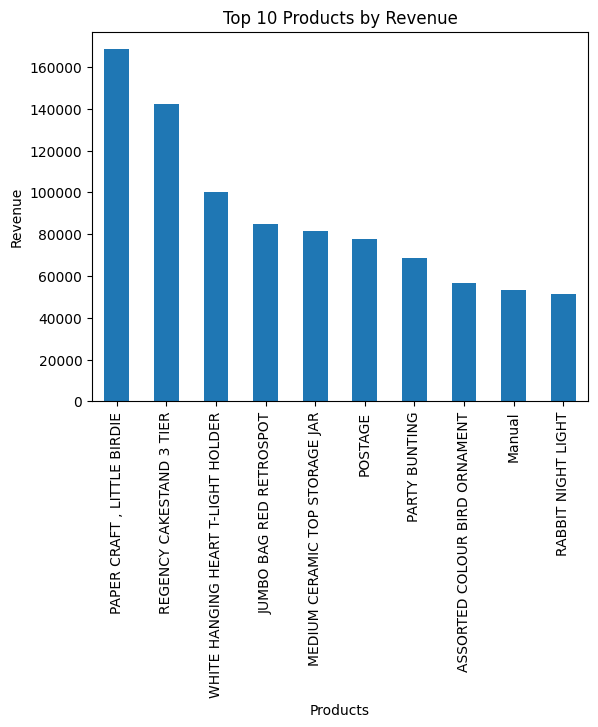

In [68]:
top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

In [69]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

top_countries

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


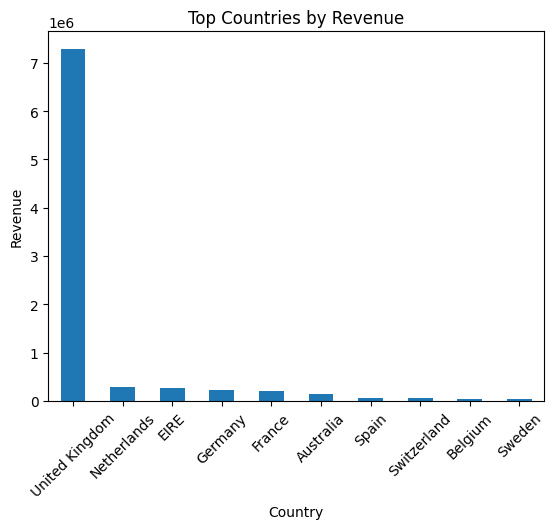

In [70]:
top_countries.plot(kind='bar')

plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [71]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)